<a href="https://colab.research.google.com/github/ivan-penta/proyecto_cidam/blob/main/proyecto_cidam_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Entorno Pyspark

In [1]:
# 1. Instalar Java 17 y PySpark
!apt-get update -qq
!apt-get install openjdk-17-jdk -y
!pip install pyspark==4.0.1 -q

# 2. Configurar variables de entorno
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"
os.environ["PATH"] = os.environ["JAVA_HOME"] + "/bin:" + os.environ["PATH"]

# 3. Verificar instalación de Java
!java -version

# 4. Crear SparkSession
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Analisis Compranet Big Data") \
    .master("local[*]") \
    .config("spark.driver.memory", "8g") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .config("spark.driver.maxResultSize", "4g") \
    .getOrCreate()

print("✅ SparkSession creada")
print("Versión:", spark.version)
print("App Name:", spark.sparkContext.appName)
print("Master:", spark.sparkContext.master)

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
openjdk-17-jdk is already the newest version (17.0.18+8-1~22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 15 not upgraded.
openjdk version "17.0.18" 2026-01-20
OpenJDK Runtime Environment (build 17.0.18+8-Ubuntu-122.04.1)
OpenJDK 64-Bit Server VM (build 17.0.18+8-Ubuntu-122.04.1, mixed mode, sharing)
✅ SparkSession creada
Versión: 4.0.1
App Name: Analisis Compranet Big Data
Master: local[*]


### Cargar dataset

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, expr

spark = SparkSession.builder \
    .appName("Analisis Compranet Big Data") \
    .getOrCreate()

print("📂 Cargando dataset completo de CompraNet...")


data = spark.read \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .option("multiLine", "true") \
    .option("escape", "\"") \
    .csv("compranet_historico.csv")

data = data.withColumn(
    "importe",
    expr("try_cast(importe as double)")
)

conteo_nulos = data.filter(col("importe").isNull()).count()
print(f"⚠️ Registros con formato inválido convertidos a NULL: {conteo_nulos}")

total_registros = data.count()
print(f"📊 Total de registros procesados: {total_registros:,}")

data.write.mode("overwrite").parquet("compranet_historico.parquet")
print("💾 Dataset completo guardado exitosamente en formato Parquet.")

📂 Cargando dataset completo de CompraNet...
⚠️ Registros con formato inválido convertidos a NULL: 5188
📊 Total de registros procesados: 2,356,612
💾 Dataset completo guardado exitosamente en formato Parquet.


### Limpieza de nulos

In [3]:
from pyspark.sql.functions import col

registros_antes = data.count()

data = data.dropna(subset=[
    "importe",
    "ff_fecha_inicio",
    "ff_fecha_fin"
])

registros_despues = data.count()
print(f"Registros antes de limpieza: {registros_antes:,}")
print(f"Registros después de limpieza: {registros_despues:,}")
print(f"Registros eliminados: {registros_antes - registros_despues:,}")

Registros antes de limpieza: 2,356,612
Registros después de limpieza: 2,347,566
Registros eliminados: 9,046


### Selección de variables

In [4]:
from pyspark.sql.functions import col

df = data.select(
    "codigo_contrato",
    "codigo_expediente",
    "proveedor",
    "contract_type",
    "tipo_contratacion",
    "tipo_expediente",
    "importe",
    "moneda",
    "fecha_inicio",
    "fecha_fin"
)

df.show(5)

+---------------+-----------------+--------------------+---------------+--------------------+--------------------+----------+------+--------------------+--------------------+
|codigo_contrato|codigo_expediente|           proveedor|  contract_type|   tipo_contratacion|     tipo_expediente|   importe|moneda|        fecha_inicio|           fecha_fin|
+---------------+-----------------+--------------------+---------------+--------------------+--------------------+----------+------+--------------------+--------------------+
|        2376191|          2161394|Equity Appraisal ...|    3.Servicios|           Servicios|05. Adjudicación ...|   89012.0|   MXN|2020-07-22 05:00:...|2020-08-27 04:59:...|
|             89|              348|Si Vale Mexico Sa...|ADQUISICIONES_0|No especificado p...|V20151220 12. Adj...| 5980292.7|   MXN|2010-12-06 06:00:...|2011-01-01 05:59:...|
|           1756|              399|Metlife Mexico Sa...|    SERVICIOS_1|No especificado p...|V20110525 01. Lic...| 3904647.0|

### Conversión de fechas y variable año

In [5]:
from pyspark.sql.functions import to_timestamp, year, col

df = df.withColumn("fecha_inicio", to_timestamp(col("fecha_inicio")))
df = df.withColumn("fecha_fin", to_timestamp(col("fecha_fin")))
df = df.filter(col("fecha_inicio").isNotNull())
df = df.withColumn("anio", year(col("fecha_inicio")))

df.select("fecha_inicio", "anio").show(5)

+-------------------+----+
|       fecha_inicio|anio|
+-------------------+----+
|2020-07-22 05:00:00|2020|
|2010-12-06 06:00:00|2010|
|2011-01-01 06:00:00|2011|
|2011-01-01 06:00:00|2011|
|2011-01-01 06:00:00|2011|
+-------------------+----+
only showing top 5 rows


### Filtro del periodo de estudio

In [6]:
from pyspark.sql.functions import to_date, lit

df = df.filter(
    (col("fecha_inicio") >= to_date(lit("2012-12-01"))) &
    (col("fecha_inicio") <= to_date(lit("2024-11-30")))
).filter(col("fecha_inicio").isNotNull())

print(f"Registros en periodo de estudio: {df.count():,}")

Registros en periodo de estudio: 2,052,702


### Creación de Variable Sexenio

In [7]:
from pyspark.sql.functions import when, to_timestamp, lit

df = df.withColumn(
    "sexenio",
    when(
        (col("fecha_inicio") >= to_timestamp(lit("2012-12-01 00:00:00"))) &
        (col("fecha_inicio") <  to_timestamp(lit("2018-12-01 00:00:00"))),
        "EPN"
    ).when(
        (col("fecha_inicio") >= to_timestamp(lit("2018-12-01 00:00:00"))) &
        (col("fecha_inicio") <  to_timestamp(lit("2024-12-01 00:00:00"))),
        "AMLO"
    )
)

df.groupBy("sexenio").count().show()

+-------+-------+
|sexenio|  count|
+-------+-------+
|    EPN|1270084|
|   AMLO| 782618|
+-------+-------+



### Ajuste por inflación

In [8]:
from pyspark.sql.functions import create_map, lit, col
from itertools import chain

#INPC base 2018
inpc = {
    2012: 47.23, 2013: 49.04, 2014: 51.10,
    2015: 52.36, 2016: 54.53, 2017: 57.71,
    2018: 61.20,
    2019: 65.28, 2020: 68.01, 2021: 72.58,
    2022: 80.95, 2023: 87.62, 2024: 92.10
}

inpc_map = create_map([lit(x) for x in chain(*inpc.items())])
INPC_BASE = 61.20

df = df.withColumn("inpc_anio", inpc_map[col("anio")]) \
  .withColumn(
      "importe_real",
      col("importe") * lit(INPC_BASE) / col("inpc_anio")
  )

  # verificar nulos tras la conversión
null_real = df.filter(col("importe_real").isNotNull())
print(f"Registros válidos tras ajuste: {df.count()}")

Registros válidos tras ajuste: 2052702


### Estadísticas descriptivas por sexenio

In [9]:
from pyspark.sql.functions import avg, sum, count, percentile_approx, round as spark_round, format_number

descriptivo = df.groupBy("sexenio").agg(
    count("*").alias("num_contratos"),
    spark_round(sum("importe_real"), 2).alias("importe_total"),
    spark_round(avg("importe_real"), 2).alias("importe_medio"),
    spark_round(
        percentile_approx("importe_real", 0.5).cast("double"), 2
    ).alias("importe_mediana")
)

descriptivo.select(
    "sexenio",
    format_number("num_contratos", 0).alias("contratos"),
    format_number("importe_total", 2).alias("total_real"),
    format_number("importe_medio", 2).alias("media_real"),
    format_number("importe_mediana", 2).alias("mediana_real")
).show(truncate=False)

+-------+---------+--------------------+------------+------------+
|sexenio|contratos|total_real          |media_real  |mediana_real|
+-------+---------+--------------------+------------+------------+
|EPN    |1,270,084|3,222,897,523,224.11|2,537,546.75|139,435.40  |
|AMLO   |782,618  |1,938,538,504,416.51|2,476,991.97|105,429.68  |
+-------+---------+--------------------+------------+------------+



### Modalidades de contratación por sexenio

In [10]:
from pyspark.sql.functions import count, round as spark_round, col

modalidades = df.groupBy("sexenio", "tipo_contratacion").count()

total_sexenio = df.groupBy("sexenio").agg(count("*").alias("total"))

modalidades_pct = modalidades.join(total_sexenio, "sexenio") \
    .withColumn(
        "porcentaje",
        spark_round(col("count") / col("total") * 100, 2)
    )

modalidades_pct.orderBy("sexenio", col("count").desc()).show(20, truncate=False)

+-------+--------------------------------+------+-------+----------+
|sexenio|tipo_contratacion               |count |total  |porcentaje|
+-------+--------------------------------+------+-------+----------+
|AMLO   |Adquisiciones                   |478476|782618 |61.14     |
|AMLO   |Servicios                       |242061|782618 |30.93     |
|AMLO   |Obra Pública                    |35050 |782618 |4.48      |
|AMLO   |Sin dato                        |13096 |782618 |1.67      |
|AMLO   |Servicios Relacionados con la OP|9526  |782618 |1.22      |
|AMLO   |Arrendamientos                  |4409  |782618 |0.56      |
|EPN    |Adquisiciones                   |647848|1270084|51.01     |
|EPN    |Servicios                       |440442|1270084|34.68     |
|EPN    |Obra Pública                    |143863|1270084|11.33     |
|EPN    |Servicios Relacionados con la OP|26888 |1270084|2.12      |
|EPN    |Arrendamientos                  |7953  |1270084|0.63      |
|EPN    |Sin dato                 

### Tipo de procedimiento

In [11]:
from pyspark.sql.functions import when, col

df = df.withColumn(
    "tipo_procedimiento",
    when(col("tipo_expediente").like("%Adjudicación Directa%"), "ADJUDICACION_DIRECTA")
    .when(col("tipo_expediente").like("%Invitación%"), "INVITACION_3")
    .when(col("tipo_expediente").like("%Licitación Pública%"), "LICITACION_PUBLICA")
    .otherwise("OTROS")
)

df.groupBy("tipo_procedimiento").count().orderBy(col("count").desc()).show()

+--------------------+-------+
|  tipo_procedimiento|  count|
+--------------------+-------+
|ADJUDICACION_DIRECTA|1530909|
|  LICITACION_PUBLICA| 271660|
|        INVITACION_3| 197839|
|               OTROS|  52294|
+--------------------+-------+



### Adjudicación directa por sexenio

In [12]:
from pyspark.sql.functions import count, round as spark_round, format_number, col

adj_sexenio  = df.groupBy("sexenio", "tipo_procedimiento").count()
total_sexenio = df.groupBy("sexenio").agg(count("*").alias("total"))

adj_pct = adj_sexenio.join(total_sexenio, "sexenio") \
    .withColumn(
        "porcentaje",
        format_number(col("count") / col("total") * 100, 2)
    )

adj_pct.orderBy("sexenio").show(20)

+-------+--------------------+------+-------+----------+
|sexenio|  tipo_procedimiento| count|  total|porcentaje|
+-------+--------------------+------+-------+----------+
|   AMLO|ADJUDICACION_DIRECTA|600200| 782618|     76.69|
|   AMLO|  LICITACION_PUBLICA| 90571| 782618|     11.57|
|   AMLO|               OTROS| 38776| 782618|      4.95|
|   AMLO|        INVITACION_3| 53071| 782618|      6.78|
|    EPN|ADJUDICACION_DIRECTA|930709|1270084|     73.28|
|    EPN|  LICITACION_PUBLICA|181089|1270084|     14.26|
|    EPN|        INVITACION_3|144768|1270084|     11.40|
|    EPN|               OTROS| 13518|1270084|      1.06|
+-------+--------------------+------+-------+----------+



### Duración promedio de contratos

In [13]:
from pyspark.sql.functions import datediff, avg, round as spark_round

df = df.withColumn(
    "duracion_dias",
    datediff(col("fecha_fin"), col("fecha_inicio"))
)

dura_sexenio = df.groupBy("sexenio").agg(
    spark_round(avg("duracion_dias"), 2).alias("duracion_promedio")
)

dura_sexenio.show()

+-------+-----------------+
|sexenio|duracion_promedio|
+-------+-----------------+
|    EPN|           111.29|
|   AMLO|           122.62|
+-------+-----------------+



### Top proveedores por sexenio y HHI

In [14]:
from pyspark.sql.functions import sum, col, format_number, pow, round as spark_round
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number

# Top 10 por sexenio
proveedores_monto = df.groupBy("sexenio", "proveedor").agg(
    sum("importe_real").alias("monto_total")
)

window = Window.partitionBy("sexenio").orderBy(col("monto_total").desc())

proveedores_monto.withColumn("rank", row_number().over(window)) \
    .filter(col("rank") <= 10) \
    .select(
        "sexenio", "proveedor",
        format_number("monto_total", 2).alias("monto_total"),
        "rank"
    ).show(truncate=False)

# HHI
gasto_total = df.groupBy("sexenio").agg(sum("importe_real").alias("gasto_total"))

participacion = proveedores_monto.join(gasto_total, "sexenio") \
    .withColumn("s_i", col("monto_total") / col("gasto_total"))

hhi = participacion.withColumn("s2", pow(col("s_i"), 2)) \
    .groupBy("sexenio").agg(sum("s2").alias("HHI"))

print("\nÍndice de Herfindahl-Hirschman (HHI):")
hhi.show()
print("Referencia: HHI < 0.01 baja concentración | 0.01-0.18 moderada | > 0.18 alta")

+-------+--------------------------------------------------------------------+------------------+----+
|sexenio|proveedor                                                           |monto_total       |rank|
+-------+--------------------------------------------------------------------+------------------+----+
|AMLO   |Electromecanica de Montacargas Sa de Cv                             |60,521,056,820.95 |1   |
|AMLO   |Toka Internacional S a P I de Cv                                    |44,289,797,258.02 |2   |
|AMLO   |Alstom Transport Mexico Sa de Cv                                    |26,578,286,394.23 |3   |
|AMLO   |Ica Constructora Sa de Cv                                           |24,898,628,876.81 |4   |
|AMLO   |Currie & Brown - Mexico Sa de Cv                                    |21,745,478,093.14 |5   |
|AMLO   |Farmaceuticos Maypo, S.A. de C.V.                                   |20,606,706,537.66 |6   |
|AMLO   |Laboratorios de Biologicos y Reactivos de Mexico Sa de Cv       

### Prueba *t* y *Mann-Whitney* para importe y duración

In [15]:
from scipy.stats import ttest_ind, mannwhitneyu
import pandas as pd

pdf = df.select("sexenio", "importe_real", "duracion_dias").dropna().toPandas()

epn = pdf[pdf["sexenio"] == "EPN"]
amlo = pdf[pdf["sexenio"] == "AMLO"]

print("Pruebas para importe real (año base 2018)")

# Prueba *t* de Welch (no se asume varianzas iguales)

t_stat, p_t = ttest_ind(epn["importe_real"], amlo["importe_real"], equal_var = False)
print(f"\nPrueba t de Welch:")
print(f"  t = {t_stat:.4f}  | p-value = {p_t:.2e}")
print(f" {'Se rechaza H0' if p_t < 0.05 else 'No se rechaza H0'} (α=0.05)")

# Prueba Mann-Whitney U (no paramétrica)

u_stat, p_mw = mannwhitneyu(epn["importe_real"], amlo["importe_real"], alternative="two-sided")
print(f"\nPrueba Mann-Whitney U:")
print(f"  U = {u_stat:.4f}  | p-value = {p_mw:.2e}")
print(f" {'Se rechaza H0' if p_mw < 0.05 else 'No se rechaza H0'} (α=0.05)")

print("\nPrueba para duración de contratos")

t_d, p_td =ttest_ind(epn["duracion_dias"], amlo["duracion_dias"], equal_var = False)
print(f"\nPrueba t de Welch:")
print(f"  t = {t_d:.4f}  | p-value = {p_td:.2e}")
print(f" {'Se rechaza H0' if p_td < 0.05 else 'No se rechaza H0'} (α=0.05)")

u_d, p_mwd = mannwhitneyu(epn["duracion_dias"], amlo["duracion_dias"], alternative="two-sided")

print(f"\nPrueba Mann-Whitney U:")
print(f"  U = {u_d:.4f}  | p-value = {p_mwd:.2e}")
print(f"  {'Se rechaza H0' if p_mwd < 0.05 else 'No se rechaza H0'} (α=0.05)")

Pruebas para importe real (año base 2018)

Prueba t de Welch:
  t = 0.4308  | p-value = 6.67e-01
 No se rechaza H0 (α=0.05)

Prueba Mann-Whitney U:
  U = 543302089168.0000  | p-value = 0.00e+00
 Se rechaza H0 (α=0.05)

Prueba para duración de contratos

Prueba t de Welch:
  t = -44.6357  | p-value = 0.00e+00
 Se rechaza H0 (α=0.05)

Prueba Mann-Whitney U:
  U = 489594656149.0000  | p-value = 1.85e-72
  Se rechaza H0 (α=0.05)


### Chi-cuadrada + Prueba Z

In [16]:
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest
import numpy as np
import pandas as pd

tabla = df.groupBy("sexenio", "tipo_procedimiento").count().toPandas()

pivot = tabla.pivot(
    index="sexenio",
    columns="tipo_procedimiento",
    values="count"
).fillna(0)

chi2, p, dof, expected = chi2_contingency(pivot)
n = pivot.values.sum()
k = min(pivot.shape) - 1
cramers_v = np.sqrt(chi2 / (n * k))

print("=" * 50)
print("Chi-cuadrada — distribución de modalidades")
print("=" * 50)
print(f"Chi² = {chi2:,.2f} | p-value = {p:.2e} | gl = {dof}")
print(f"V de Cramér = {cramers_v:.4f}  (efecto {'débil' if cramers_v < 0.1 else 'moderado' if cramers_v < 0.3 else 'fuerte'})")

# Prueba Z de diferencia de proporciones para adjudicación directa
print("\n" + "=" * 50)
print("Prueba Z — proporción de adjudicación directa")
print("=" * 50)

n_epn  = int(pivot.loc["EPN"].sum())
n_amlo = int(pivot.loc["AMLO"].sum())
adj_epn  = int(pivot.loc["EPN",  "ADJUDICACION_DIRECTA"])
adj_amlo = int(pivot.loc["AMLO", "ADJUDICACION_DIRECTA"])

p1 = adj_epn  / n_epn
p2 = adj_amlo / n_amlo

z_stat, p_z = proportions_ztest([adj_epn, adj_amlo], [n_epn, n_amlo])

print(f"Proporción EPN:  {p1:.4f} ({adj_epn:,} / {n_epn:,})")
print(f"Proporción AMLO: {p2:.4f} ({adj_amlo:,} / {n_amlo:,})")
print(f"Z = {z_stat:.4f} | p-value = {p_z:.2e}")
print(f"{'Se rechaza H0' if p_z < 0.05 else 'No se rechaza H0'} (α=0.05)")

Chi-cuadrada — distribución de modalidades
Chi² = 42,871.85 | p-value = 0.00e+00 | gl = 3
V de Cramér = 0.1445  (efecto moderado)

Prueba Z — proporción de adjudicación directa
Proporción EPN:  0.7328 (930,709 / 1,270,084)
Proporción AMLO: 0.7669 (600,200 / 782,618)
Z = -54.5302 | p-value = 0.00e+00
Se rechaza H0 (α=0.05)


### Series de tiempo

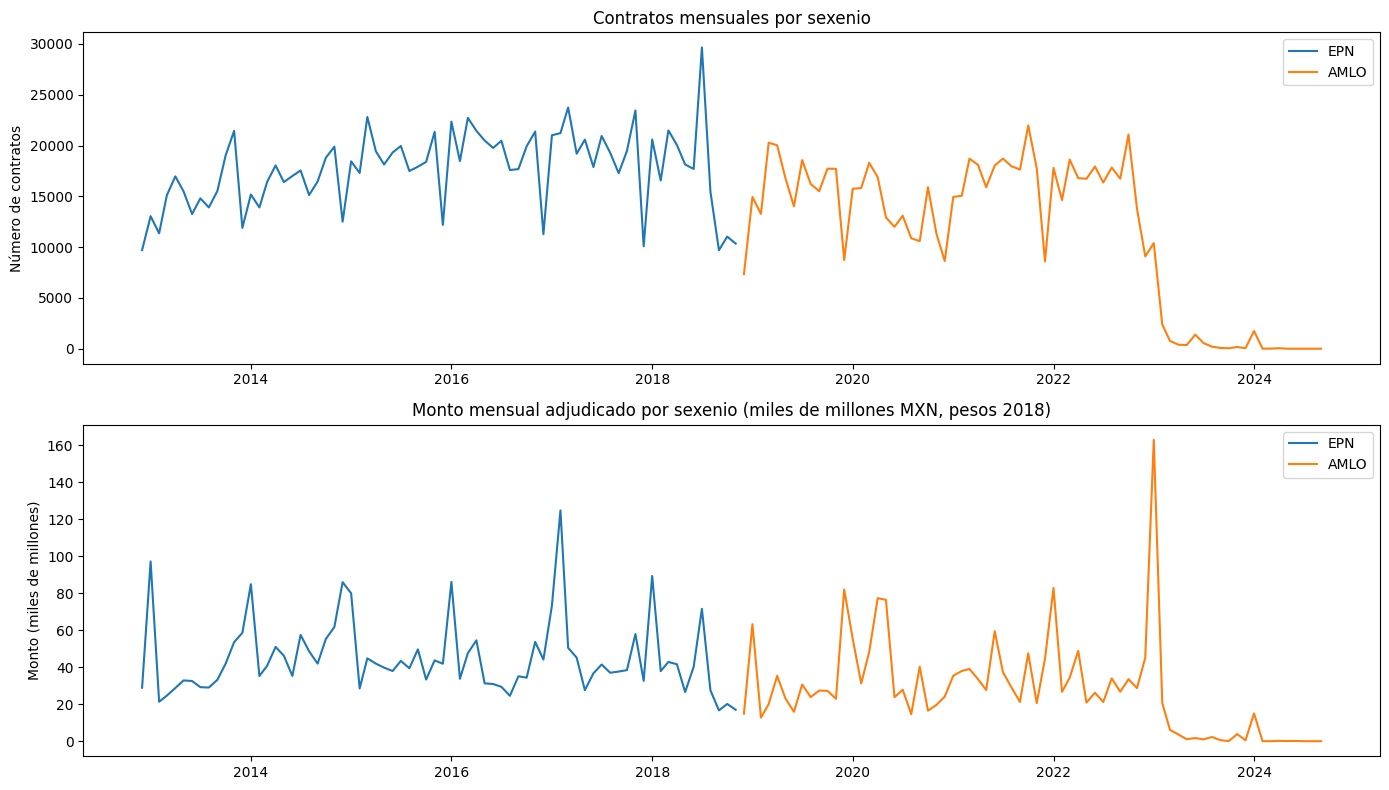

In [17]:
from pyspark.sql.functions import month, sum, count, col, format_number, lpad, concat_ws
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Serie mensual: número de contratos y monto adjudicado
df_ts = df.withColumn("mes", month(col("fecha_inicio")))

serie_mensual = df_ts.groupBy("sexenio", "anio", "mes").agg(
    count("*").alias("num_contratos"),
    sum("importe_real").alias("monto_total")
).orderBy("anio", "mes")

ts_pd = serie_mensual.toPandas()

# Construir fecha como primer día del mes para graficar
ts_pd["fecha"] = pd.to_datetime(
    ts_pd["anio"].astype(str) + "-" + ts_pd["mes"].astype(str).str.zfill(2) + "-01"
)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

for s, color in [("EPN", "#1f77b4"), ("AMLO", "#ff7f0e")]:
    subset = ts_pd[ts_pd["sexenio"] == s].sort_values("fecha")
    axes[0].plot(subset["fecha"], subset["num_contratos"], label=s, color=color)
    axes[1].plot(subset["fecha"], subset["monto_total"] / 1e9, label=s, color=color)

axes[0].set_title("Contratos mensuales por sexenio")
axes[0].set_ylabel("Número de contratos")
axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

axes[1].set_title("Monto mensual adjudicado por sexenio (miles de millones MXN, pesos 2018)")
axes[1].set_ylabel("Monto (miles de millones)")
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.show()

### Regresión temporal con variable dummy por sexenio

Modelo 1 — Tendencia temporal simple
  β₀ (intercepto) =      493,559,041,486  |  p = 0.0005
  β₁ (tendencia)  =      -16,087,583,483  |  p = 0.2899
  R²              = 0.1010
  → Tendencia NO significativa (α=0.05)

Modelo 2 — Cambio estructural (dummy de sexenio)
                            OLS Regression Results                            
Dep. Variable:            monto_total   R-squared:                       0.488
Model:                            OLS   Adj. R-squared:                  0.317
Method:                 Least Squares   F-statistic:                     2.859
Date:                Mon, 23 Mar 2026   Prob (F-statistic):             0.0968
Time:                        16:16:52   Log-Likelihood:                -351.67
No. Observations:                  13   AIC:                             711.3
Df Residuals:                       9   BIC:                             713.6
Df Model:                           3                                         
Covariance Type:       

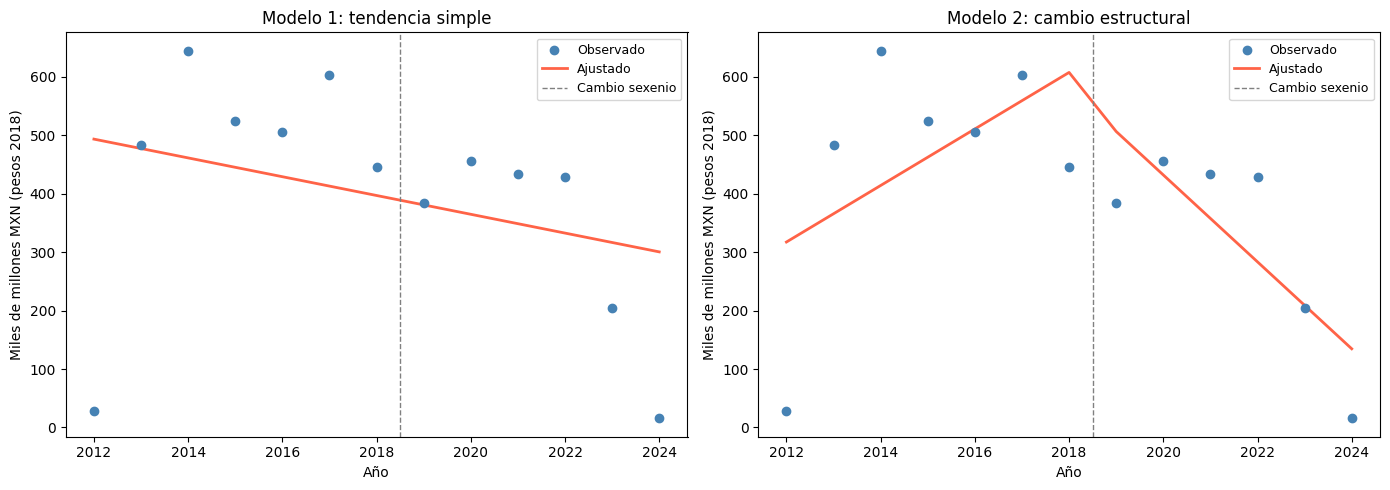

In [18]:
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from pyspark.sql.functions import sum as spark_sum, count, col

# Serie anual
ts_raw = df.groupBy("anio").agg(
    spark_sum("importe_real").alias("monto_total"),
    count("*").alias("num_contratos")
).orderBy("anio").toPandas()

# Variables del modelo
ts_raw["t"]      = ts_raw["anio"] - 2012
ts_raw["D_amlo"] = (ts_raw["anio"] >= 2019).astype(int)
ts_raw["t_amlo"] = ts_raw["t"] * ts_raw["D_amlo"]

y = ts_raw["monto_total"]

# Modelo 1: tendencia simple
X1 = sm.add_constant(ts_raw[["t"]])
m1 = sm.OLS(y, X1).fit()

print("=" * 55)
print("Modelo 1 — Tendencia temporal simple")
print("=" * 55)
print(f"  β₀ (intercepto) = {m1.params['const']:>20,.0f}  |  p = {m1.pvalues['const']:.4f}")
print(f"  β₁ (tendencia)  = {m1.params['t']:>20,.0f}  |  p = {m1.pvalues['t']:.4f}")
print(f"  R²              = {m1.rsquared:.4f}")
print(f"  → Tendencia {'significativa' if m1.pvalues['t'] < 0.05 else 'NO significativa'} (α=0.05)")

# Modelo 2: cambio estructural
X2 = sm.add_constant(ts_raw[["t", "D_amlo", "t_amlo"]])
m2 = sm.OLS(y, X2).fit()

print("\n" + "=" * 55)
print("Modelo 2 — Cambio estructural (dummy de sexenio)")
print("=" * 55)
print(m2.summary())

print("\nInterpretación:")
print(f"  β₁ (tendencia EPN)  = {m2.params['t']:>20,.0f}  p={m2.pvalues['t']:.4f}")
print(f"  D_AMLO              = {m2.params['D_amlo']:>20,.0f}  p={m2.pvalues['D_amlo']:.4f}  → cambio de nivel")
print(f"  t × D_AMLO          = {m2.params['t_amlo']:>20,.0f}  p={m2.pvalues['t_amlo']:.4f}  → cambio de pendiente")


ts_raw["fitted_m1"] = m1.fittedvalues
ts_raw["fitted_m2"] = m2.fittedvalues

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col_fit, title in [
    (axes[0], "fitted_m1", "Modelo 1: tendencia simple"),
    (axes[1], "fitted_m2", "Modelo 2: cambio estructural"),
]:
    ax.scatter(ts_raw["anio"], ts_raw["monto_total"] / 1e9,
               color="steelblue", zorder=3, label="Observado")
    ax.plot(ts_raw["anio"], ts_raw[col_fit] / 1e9,
            color="tomato", linewidth=2, label="Ajustado")
    ax.axvline(2018.5, color="gray", linestyle="--", linewidth=1, label="Cambio sexenio")
    ax.set_title(title)
    ax.set_xlabel("Año")
    ax.set_ylabel("Miles de millones MXN (pesos 2018)")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

### Regresión multivariada

In [19]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np

# Se toma muestra de 200k registros manteniendo proporción por sexenio
pdf_reg = df.select(
    "importe_real", "sexenio", "duracion_dias", "tipo_procedimiento"
).dropna().sample(fraction=0.10, seed=42).toPandas()

# Variables independientes
pdf_reg["log_importe"]   = np.log1p(pdf_reg["importe_real"])
pdf_reg["D_amlo"]        = (pdf_reg["sexenio"] == "AMLO").astype(int)
pdf_reg["log_duracion"]  = np.log1p(pdf_reg["duracion_dias"].clip(lower=0))

# Dummies de modalidad
dummies = pd.get_dummies(pdf_reg["tipo_procedimiento"], drop_first=True, dtype=float)
pdf_reg = pd.concat([pdf_reg, dummies], axis=1)

vars_x = ["D_amlo", "log_duracion"] + list(dummies.columns)
X = sm.add_constant(pdf_reg[vars_x])
y = pdf_reg["log_importe"]

modelo = sm.OLS(y, X).fit()
print(modelo.summary())

# Diagnóstico de multicolinealidad (VIF)
print("\nFactor de Inflación de la Varianza (VIF):")
vif_data = pd.DataFrame({
    "Variable": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
print(vif_data[vif_data["Variable"] != "const"].to_string(index=False))
print("\nReferencia: VIF < 5 aceptable | VIF > 10 multicolinealidad grave")

                            OLS Regression Results                            
Dep. Variable:            log_importe   R-squared:                       0.219
Model:                            OLS   Adj. R-squared:                  0.219
Method:                 Least Squares   F-statistic:                 1.152e+04
Date:                Mon, 23 Mar 2026   Prob (F-statistic):               0.00
Time:                        16:17:45   Log-Likelihood:            -4.1936e+05
No. Observations:              205284   AIC:                         8.387e+05
Df Residuals:                  205278   BIC:                         8.388e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 10.3922      0

### Pipeline (random forest)

In [20]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml import Pipeline
from pyspark.sql.functions import log1p, month, dayofweek, col

# Features adicionales
df_ml = df.withColumn("log_importe",  log1p(col("importe"))) \
           .withColumn("mes_inicio",   month(col("fecha_inicio"))) \
           .withColumn("dia_semana",   dayofweek(col("fecha_inicio")))

# Limpiar columnas previas si existen
for c in ["label", "tipo_idx", "tipo_ohe", "features"]:
    if c in df_ml.columns:
        df_ml = df_ml.drop(c)

indexer_sexenio = StringIndexer(inputCol="sexenio", outputCol="label")
indexer_tipo    = StringIndexer(inputCol="tipo_contratacion", outputCol="tipo_idx",
                                handleInvalid="keep")
encoder         = OneHotEncoder(inputCols=["tipo_idx"], outputCols=["tipo_ohe"])
assembler       = VectorAssembler(
    inputCols=["log_importe", "duracion_dias", "mes_inicio", "dia_semana", "tipo_ohe"],
    outputCol="features",
    handleInvalid="skip"
)

pipeline = Pipeline(stages=[indexer_sexenio, indexer_tipo, encoder, assembler])
df_ml = pipeline.fit(df_ml).transform(df_ml)
print("Pipeline ejecutado correctamente")

Pipeline ejecutado correctamente


### Random Forest

In [21]:
from pyspark.ml.classification import RandomForestClassifier

train = df_ml.filter(
    ((col("sexenio") == "EPN")  & (col("anio") <= 2016)) |
    ((col("sexenio") == "AMLO") & (col("anio") <= 2020))
)
test = df_ml.filter(
    ((col("sexenio") == "EPN")  & (col("anio").isin([2017, 2018]))) |
    ((col("sexenio") == "AMLO") & (col("anio").isin([2023, 2024])))
)

print(f"Train: {train.count():,} | Test: {test.count():,}")

rf = RandomForestClassifier(
    labelCol="label", featuresCol="features",
    numTrees=100, maxDepth=8, seed=42
)
model = rf.fit(train)
pred  = model.transform(test)

Train: 1,208,379 | Test: 443,545


### Métricas + AUC-ROC

In [24]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator
from pyspark.sql.functions import when, col
import pandas as pd

print("Métricas de clasificación - Random Forest")

for metric in ["accuracy", "weightedPrecision", "weightedRecall", "f1"]:
  val = MulticlassClassificationEvaluator(
      labelCol="label", predictionCol = "prediction", metricName=metric
  ).evaluate(pred)
  print(f"\n {metric:20s}: {val:.4f}")

# AUC-ROC
auc = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
).evaluate(pred)
print(f"\n {'AUC-ROC':20s}: {auc:.4f}")

# Matriz de confusión

print("\nMatriz de confusión:")
pred.withColumn(
        "sexenio_pred",
        when(col("prediction") == 0, "EPN").otherwise("AMLO")
    ).groupBy("sexenio", "sexenio_pred").count().orderBy("sexenio").show()

# Importancia de features
feature_names = (
          ["log_importe", "duracion_dias", "mes_inicio", "dia_semana"] +
          [f"tipo_ohe_{i}" for i in range(model.featureImportances.size - 4)]
      )

importancias = pd.Series(
          model.featureImportances.toArray(),
          index=feature_names[:model.featureImportances.size]
      ).sort_values(ascending=False)

print("\nImportancia de features:")
print(importancias.head(10))


Métricas de clasificación - Random Forest

 accuracy            : 0.9582

 weightedPrecision   : 0.9415

 weightedRecall      : 0.9582

 f1                  : 0.9391

 AUC-ROC             : 0.7977

Matriz de confusión:
+-------+------------+------+
|sexenio|sexenio_pred| count|
+-------+------------+------+
|   AMLO|        AMLO|   377|
|   AMLO|         EPN| 18251|
|    EPN|         EPN|424606|
|    EPN|        AMLO|   311|
+-------+------------+------+


Importancia de features:
duracion_dias    0.367579
tipo_ohe_2       0.248545
log_importe      0.086903
tipo_ohe_0       0.080190
mes_inicio       0.076450
dia_semana       0.074469
tipo_ohe_1       0.039915
tipo_ohe_3       0.022637
tipo_ohe_4       0.001668
tipo_ohe_5       0.001637
dtype: float64


### Clustering k-medias

Calculando inercia para k = 2 a 8 (método del codo)...
  k=2 | inercia = 4,413,177.23
  k=3 | inercia = 3,331,179.83
  k=4 | inercia = 2,773,225.41
  k=5 | inercia = 2,299,542.70
  k=6 | inercia = 2,021,178.96
  k=7 | inercia = 1,778,177.96
  k=8 | inercia = 1,664,635.31


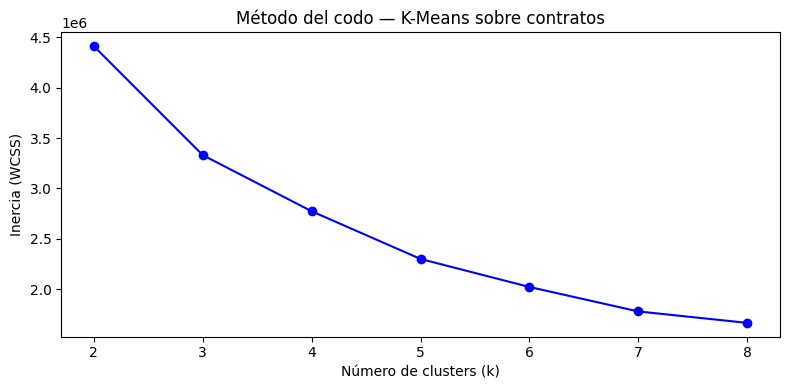


K óptimo usado: 4
Silhouette score: 0.4677  (rango -1 a 1, mayor es mejor)

Distribución de contratos por cluster:
+----------+------+
|prediction| count|
+----------+------+
|         0|665079|
|         1|520613|
|         2|825387|
|         3| 41623|
+----------+------+


Clusters por sexenio:
+-------+----------+------+
|sexenio|prediction| count|
+-------+----------+------+
|   AMLO|         0|251716|
|   AMLO|         1|199202|
|   AMLO|         2|310954|
|   AMLO|         3| 20746|
|    EPN|         0|413363|
|    EPN|         1|321411|
|    EPN|         2|514433|
|    EPN|         3| 20877|
+-------+----------+------+


Centros de clusters (escala escalada):
  Cluster 0: log_importe=-0.772, duracion=-0.375, mes=-0.531
  Cluster 1: log_importe=0.737, duracion=0.671, mes=-0.854
  Cluster 2: log_importe=0.119, duracion=-0.352, mes=0.980
  Cluster 3: log_importe=0.762, duracion=4.589, mes=-0.275


In [25]:
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
import matplotlib.pyplot as plt

# Construir features y ESCALAR (obligatorio para K-Means) ──
assembler_k = VectorAssembler(
    inputCols=["log_importe", "duracion_dias", "mes_inicio"],
    outputCol="features_raw",
    handleInvalid="skip"
)

scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features_scaled",
    withStd=True, withMean=True
)

df_k = assembler_k.transform(
    df.withColumn("log_importe", log1p(col("importe")))
      .withColumn("mes_inicio",  month(col("fecha_inicio")))
      .dropna(subset=["log_importe", "duracion_dias", "mes_inicio"])
)
scaler_model = scaler.fit(df_k)
df_k = scaler_model.transform(df_k)

# Método del codo para elegir k
print("Calculando inercia para k = 2 a 8 (método del codo)...")
inertias = []
ks = range(2, 9)

for k in ks:
    km = KMeans(k=k, seed=42, featuresCol="features_scaled", maxIter=20)
    m  = km.fit(df_k)
    inertias.append(m.summary.trainingCost)
    print(f"  k={k} | inercia = {m.summary.trainingCost:,.2f}")

plt.figure(figsize=(8, 4))
plt.plot(list(ks), inertias, "bo-")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia (WCSS)")
plt.title("Método del codo — K-Means sobre contratos")
plt.tight_layout()
plt.show()

# Ajustar con el k óptimo (elegir visualmente del codo)
K_OPTIMO = 4

km_final = KMeans(k=K_OPTIMO, seed=42, featuresCol="features_scaled", maxIter=50)
modelo_k  = km_final.fit(df_k)
df_clusters = modelo_k.transform(df_k)

# Silhouette score
silhouette = ClusteringEvaluator(
    featuresCol="features_scaled", metricName="silhouette"
).evaluate(df_clusters)
print(f"\nK óptimo usado: {K_OPTIMO}")
print(f"Silhouette score: {silhouette:.4f}  (rango -1 a 1, mayor es mejor)")

# Distribución por cluster y sexenio
print("\nDistribución de contratos por cluster:")
df_clusters.groupBy("prediction").count().orderBy("prediction").show()

print("\nClusters por sexenio:")
df_clusters.groupBy("sexenio", "prediction").count().orderBy("sexenio", "prediction").show()

# Centros de los clusters (en escala original aproximada)
print("\nCentros de clusters (escala escalada):")
for i, c in enumerate(modelo_k.clusterCenters()):
    print(f"  Cluster {i}: log_importe={c[0]:.3f}, duracion={c[1]:.3f}, mes={c[2]:.3f}")

### Modelo Logit

In [26]:
import statsmodels.api as sm
import numpy as np
import pandas as pd

# Tomar muestra para eficiencia
pdf_logit = df.select(
    "tipo_expediente", "importe_real", "duracion_dias", "anio", "sexenio"
).dropna().sample(fraction=0.10, seed=42).toPandas()

# Variable dependiente: adjudicación directa (1 = sí, 0 = no)
pdf_logit["adjudicacion"] = pdf_logit["tipo_expediente"] \
    .str.contains("Adjudicación Directa", na=False).astype(int)

# Transformar variables para evitar overflow numérico
pdf_logit["log_importe"]  = np.log1p(pdf_logit["importe_real"].clip(lower=0))
pdf_logit["log_duracion"] = np.log1p(pdf_logit["duracion_dias"].clip(lower=0))
pdf_logit["anio_c"]       = pdf_logit["anio"] - 2018  # centrar en año base

X = sm.add_constant(pdf_logit[["log_importe", "log_duracion", "anio_c"]])
y = pdf_logit["adjudicacion"]

logit_model = sm.Logit(y, X).fit(maxiter=200)
print(logit_model.summary())

# Efectos marginales (más interpretables que coeficientes brutos)
print("\nEfectos marginales en la media:")
print(logit_model.get_margeff().summary())

Optimization terminated successfully.
         Current function value: 0.442973
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:           adjudicacion   No. Observations:               205284
Model:                          Logit   Df Residuals:                   205280
Method:                           MLE   Df Model:                            3
Date:                Mon, 23 Mar 2026   Pseudo R-squ.:                  0.2188
Time:                        18:02:08   Log-Likelihood:                -90935.
converged:                       True   LL-Null:                   -1.1641e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            8.7470      0.045    196.528      0.000       8.660       8.834
log_importe     -0.4607

### Gráficas

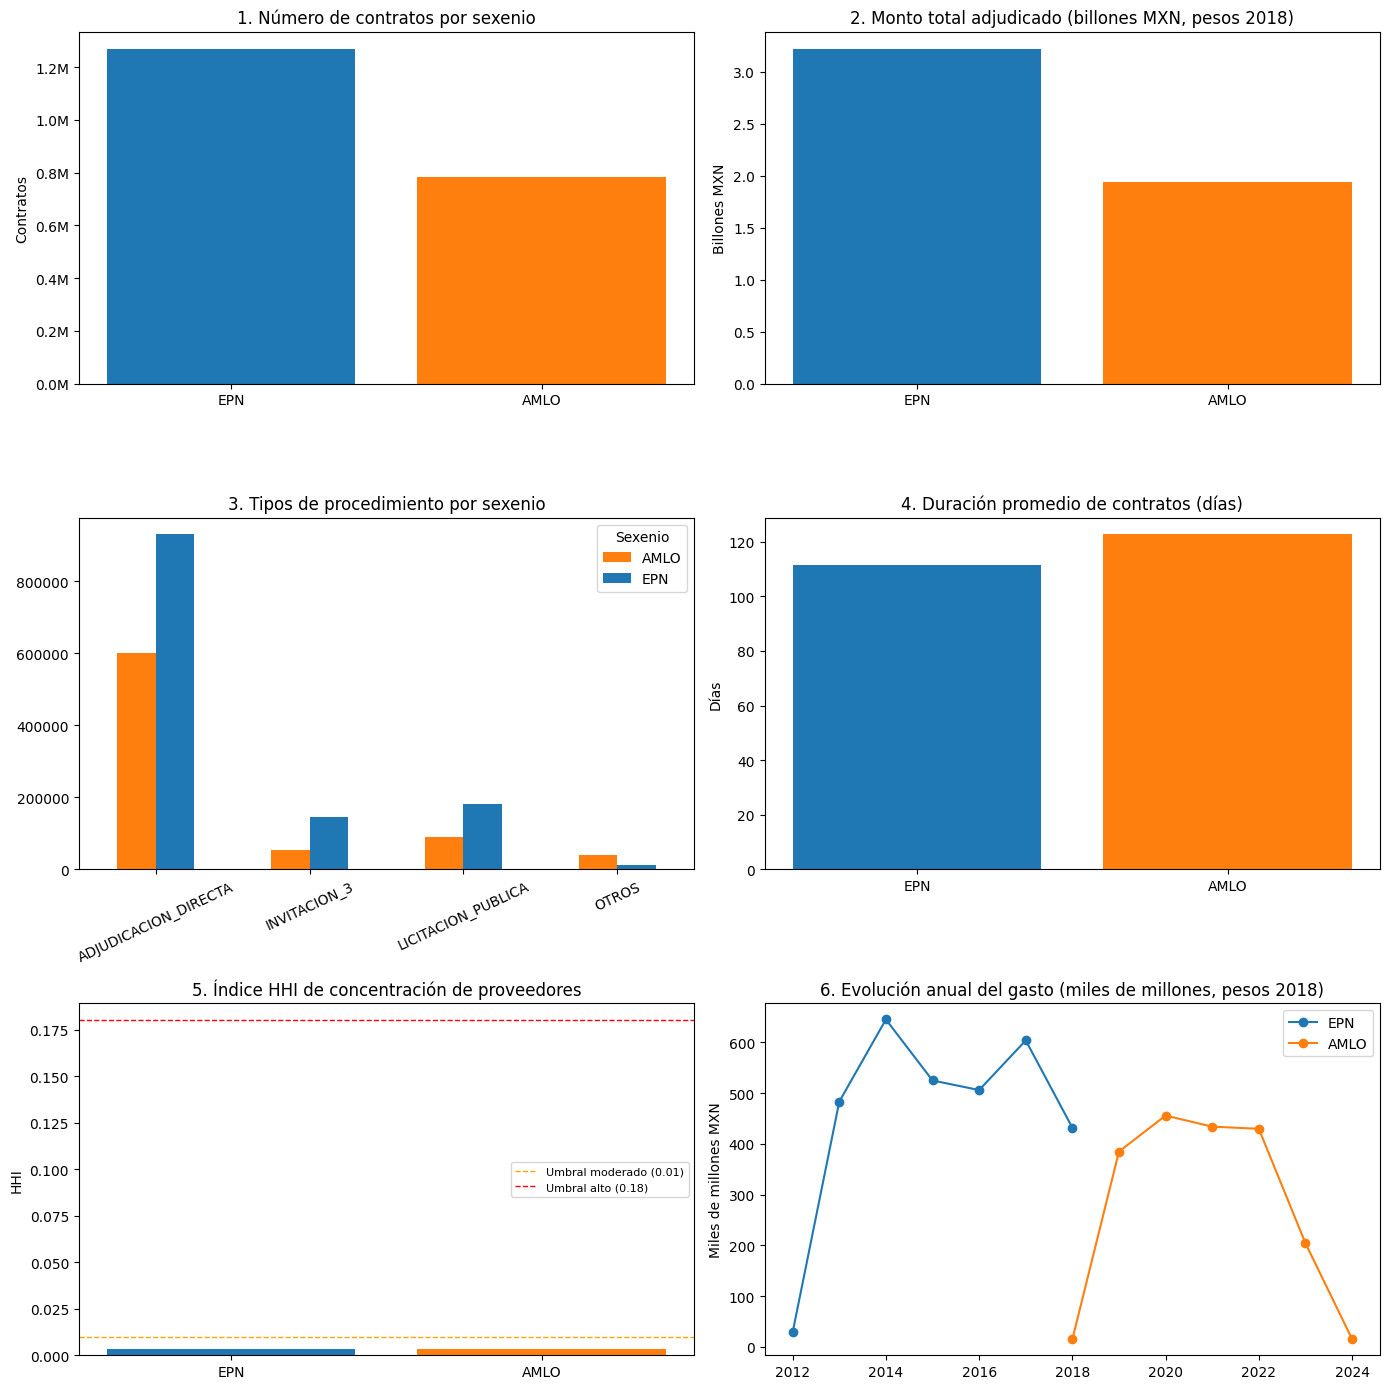

Gráficas guardadas en visualizaciones_comparativas.png


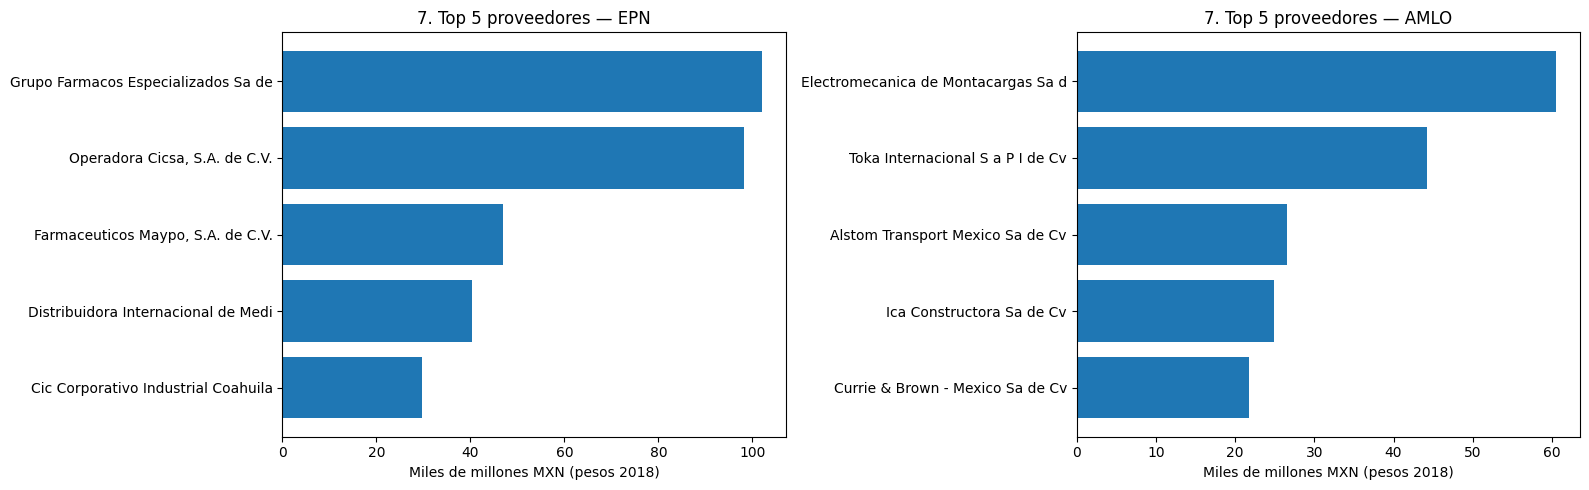

Gráfica de proveedores guardada en top_proveedores.png


In [29]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np
from pyspark.sql.functions import sum, avg, pow, col

# ── Datos necesarios en Pandas ───────────────────────────────────────
contratos_pd   = df.groupBy("sexenio").count().toPandas()
monto_pd       = df.groupBy("sexenio").agg(sum("importe_real").alias("m")).toPandas()
modalidades_pd = df.groupBy("sexenio", "tipo_procedimiento").count().toPandas()
dura_pd        = df.groupBy("sexenio").agg(avg("duracion_dias").alias("d")).toPandas()

# Top 5 proveedores por sexenio (para gráfica comparativa)
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number

prov_monto = df.groupBy("sexenio", "proveedor").agg(
    sum("importe_real").alias("monto_total")
)
window = Window.partitionBy("sexenio").orderBy(col("monto_total").desc())
top5_pd = prov_monto.withColumn("rank", row_number().over(window)) \
    .filter(col("rank") <= 5).toPandas()

# HHI
gasto_total  = df.groupBy("sexenio").agg(sum("importe_real").alias("gasto_total"))
prov_part    = prov_monto.join(gasto_total, "sexenio") \
    .withColumn("s_i", col("monto_total") / col("gasto_total"))
hhi_pd = prov_part.withColumn("s2", pow(col("s_i"), 2)) \
    .groupBy("sexenio").agg(sum("s2").alias("HHI")).toPandas()

# Serie anual
ts_anual_plot = df.groupBy("sexenio", "anio").agg(
    sum("importe_real").alias("monto")
).toPandas()

# ── Figura ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()

# 1. Contratos por sexenio
axes[0].bar(contratos_pd["sexenio"], contratos_pd["count"],
            color=["#1f77b4", "#ff7f0e"])
axes[0].set_title("1. Número de contratos por sexenio")
axes[0].set_ylabel("Contratos")
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M")
)

# 2. Monto total por sexenio
axes[1].bar(monto_pd["sexenio"], monto_pd["m"] / 1e12,
            color=["#1f77b4", "#ff7f0e"])
axes[1].set_title("2. Monto total adjudicado (billones MXN, pesos 2018)")
axes[1].set_ylabel("Billones MXN")

# 3. Modalidades de contratación
pivot_mod = modalidades_pd.pivot(
    index="tipo_procedimiento", columns="sexenio", values="count"
).fillna(0)
pivot_mod.plot(kind="bar", ax=axes[2], color=["#ff7f0e", "#1f77b4"])
axes[2].set_title("3. Tipos de procedimiento por sexenio")
axes[2].set_xlabel("")
axes[2].tick_params(axis="x", rotation=25)
axes[2].legend(title="Sexenio")

# 4. Duración promedio
axes[3].bar(dura_pd["sexenio"], dura_pd["d"],
            color=["#1f77b4", "#ff7f0e"])
axes[3].set_title("4. Duración promedio de contratos (días)")
axes[3].set_ylabel("Días")

# 5. HHI comparativo
axes[4].bar(hhi_pd["sexenio"], hhi_pd["HHI"],
            color=["#1f77b4", "#ff7f0e"])
axes[4].set_title("5. Índice HHI de concentración de proveedores")
axes[4].set_ylabel("HHI")
axes[4].axhline(0.01, color="orange", linestyle="--",
                linewidth=1, label="Umbral moderado (0.01)")
axes[4].axhline(0.18, color="red",    linestyle="--",
                linewidth=1, label="Umbral alto (0.18)")
axes[4].legend(fontsize=8)

# 6. Evolución anual del gasto
for s, c in [("EPN", "#1f77b4"), ("AMLO", "#ff7f0e")]:
    sub = ts_anual_plot[ts_anual_plot["sexenio"] == s].sort_values("anio")
    axes[5].plot(sub["anio"], sub["monto"] / 1e9,
                 label=s, color=c, marker="o")
axes[5].set_title("6. Evolución anual del gasto (miles de millones, pesos 2018)")
axes[5].set_ylabel("Miles de millones MXN")
axes[5].legend()

plt.tight_layout()
plt.savefig("visualizaciones_comparativas.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráficas guardadas en visualizaciones_comparativas.png")

# ── Gráfica adicional: top 5 proveedores por sexenio ─────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(16, 5))

for ax, sexenio in zip(axes2, ["EPN", "AMLO"]):
    sub = top5_pd[top5_pd["sexenio"] == sexenio].sort_values("monto_total")
    # Acortar nombres largos para que quepan en el eje
    nombres = sub["proveedor"].str[:35]
    ax.barh(nombres, sub["monto_total"] / 1e9)
    ax.set_title(f"7. Top 5 proveedores — {sexenio}")
    ax.set_xlabel("Miles de millones MXN (pesos 2018)")

plt.tight_layout()
plt.savefig("top_proveedores.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfica de proveedores guardada en top_proveedores.png")